In [1]:
# Hospital Performance & Patient Outcomes Analytics

## A Data-Driven Analysis of Hospital Utilization, Patient Outcomes, Efficiency, and Quality of Care

### 1. Project Introduction

Healthcare organizations generate large volumes of clinical and administrative data through patient admissions, hospital transfers, clinical encounters, and discharge processes. Proper analysis of these data can help healthcare professionals and managers understand patterns of hospital utilization, patient outcomes, and healthcare delivery.

This project analyzes hospital data from the **MIMIC-IV Clinical Database Demo** to demonstrate an end-to-end healthcare data analytics workflow.

The analysis focuses on understanding patient and hospital utilization patterns, evaluating key healthcare performance indicators, and identifying patterns in hospital stays and patient outcomes.

The project combines **Python for data preparation and exploratory analysis** with **Power BI for interactive visualization and healthcare performance reporting**.

### Project Goal

The primary goal of this project is to transform raw hospital data into meaningful healthcare insights that can support:

- Hospital performance monitoring
- Patient outcome assessment
- Resource utilization analysis
- Healthcare quality improvement
- Evidence-based management and decision-making

### Key Analytical Areas

The project will examine:

1. Patient demographics and characteristics
2. Hospital admissions and utilization
3. Hospital length of stay
4. Patient discharge outcomes
5. Hospital transfers and care-unit utilization
6. Mortality-related outcomes available in the dataset
7. Differences in healthcare utilization across patient groups
8. Key indicators for hospital performance and patient outcomes

### Analytical Workflow

The project follows an end-to-end healthcare analytics workflow:

**Raw Data → Data Understanding → Data Cleaning → Feature Engineering → Exploratory Data Analysis → Healthcare Indicators → Power BI Dashboard → Epidemiological & Healthcare Insights → Recommendations**

### Expected Outcome

The final deliverable will be an interactive **Hospital Performance & Patient Outcomes Dashboard** designed to present healthcare utilization, efficiency, and patient outcome indicators in a clear and decision-oriented format.

This project is intended as a professional healthcare data analytics portfolio project demonstrating skills in **Python, Pandas, data analysis, healthcare analytics, Power BI, DAX, data visualization, and data storytelling**.

SyntaxError: invalid character '→' (U+2192) (2031600424.py, line 42)

In [ ]:
## 2. Data Source & Dataset Description

### 2.1 Data Source

This project uses the **MIMIC-IV Clinical Database Demo**, an openly available deidentified subset of the MIMIC-IV clinical database provided through **PhysioNet** and maintained by the MIT Laboratory for Computational Physiology.

MIMIC-IV is derived from electronic health record systems at **Beth Israel Deaconess Medical Center (BIDMC)** and is designed to support research, education, and reproducible healthcare data analysis.

The MIMIC-IV Clinical Database Demo contains a subset of 100 patients and provides a simplified environment for learning and developing reproducible analyses using the MIMIC-IV data structure.

### 2.2 Dataset Characteristics

The MIMIC-IV Demo is a relational clinical database distributed in CSV format. It contains multiple modules and tables covering different aspects of patient care.

For this project, the initial analysis focuses on the **Core** module, which contains three key tables:

| Table | Description | Primary Identifier |
|---|---|---|
| `patients` | Patient-level demographic and mortality-related information | `subject_id` |
| `admissions` | Information about hospital admissions and discharge events | `hadm_id` |
| `transfers` | Patient movements between hospital care units | `transfer_id` |

These tables can be linked through common identifiers, particularly `subject_id` and `hadm_id`.

### 2.3 Core Tables Used in This Project

#### Patients

The `patients` table provides information at the patient level, including:

- `subject_id`
- `gender`
- `anchor_age`
- `anchor_year`
- `anchor_year_group`
- `dod`

This table will primarily be used to describe patient characteristics and mortality-related information.

#### Admissions

The `admissions` table contains information about individual hospitalizations, including:

- `subject_id`
- `hadm_id`
- `admittime`
- `dischtime`
- `deathtime`
- `admission_type`
- `admission_location`
- `discharge_location`
- `insurance`
- `marital_status`
- `race`
- `hospital_expire_flag`

This table will be the main source for analyzing hospital admissions, length of stay, discharge outcomes, and in-hospital mortality.

#### Transfers

The `transfers` table records movements of patients between hospital care units during a hospitalization.

Important fields include:

- `subject_id`
- `hadm_id`
- `transfer_id`
- `eventtype`
- `careunit`
- `intime`
- `outtime`

This table will be used to examine patient movement and patterns of hospital utilization.

### 2.4 Data De-identification

The MIMIC-IV dataset is deidentified to protect patient privacy. Patient identifiers are replaced with randomized identifiers, and dates are shifted while maintaining internal temporal consistency for each patient.

Therefore, the dates in this dataset should **not** be interpreted as actual calendar dates for individual patients.

The analysis in this project focuses on patterns and relationships within the deidentified dataset rather than identifying individual patients.

### 2.5 Data Scope

The analysis will initially focus on the following three Core tables:

```text
patients
    │
    │ subject_id
    ▼
admissions
    │
    │ subject_id + hadm_id
    ▼
transfers

In [ ]:
## 3. Data Loading & Initial Inspection

This section loads the MIMIC-IV Clinical Database Demo Core tables and performs an initial assessment of their structure, dimensions, data types, and data quality.

The following tables will be loaded:

- `patients`
- `admissions`
- `transfers`

The initial inspection will help identify the structure of the data before performing data cleaning and feature engineering.

In [6]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

In [7]:
data_path = Path("C:/data/raw")

In [8]:

patients = pd.read_csv(data_path / "patients.csv")
admissions = pd.read_csv(data_path / "admissions.csv")
transfers = pd.read_csv(data_path / "transfers.csv")

In [9]:
print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("Transfers:", transfers.shape)

Patients: (100, 6)
Admissions: (275, 15)
Transfers: (1190, 7)


In [10]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10008454,F,26,2110,2011 - 2013,NaN
2,10010867,F,28,2147,2014 - 2016,NaN
3,10023239,F,29,2137,2014 - 2016,NaN
4,10032725,F,38,2143,2011 - 2013,NaN


In [11]:
transfers.head()

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
0,10006053,22942076.0,39846105,transfer,NaN,2111-11-14 00:14:10,2111-11-14 00:19:12
1,10003046,26048429.0,35594790,discharge,NaN,2154-01-09 11:53:26,NaN
2,10007058,22954658.0,33737266,discharge,NaN,2167-11-11 14:26:31,NaN
3,10020944,29974575.0,37898114,discharge,NaN,2131-03-13 17:01:34,NaN
4,10002495,24982426.0,39534379,discharge,NaN,2141-05-29 17:42:52,NaN


In [12]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,ethnicity,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/AFRICAN AMERICAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [13]:
print("PATIENTS COLUMNS")
print(patients.columns.tolist())

print("\nADMISSIONS COLUMNS")
print(admissions.columns.tolist())

print("\nTRANSFERS COLUMNS")
print(transfers.columns.tolist())

PATIENTS COLUMNS
['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

ADMISSIONS COLUMNS
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'hospital_expire_flag']

TRANSFERS COLUMNS
['subject_id', 'hadm_id', 'transfer_id', 'eventtype', 'careunit', 'intime', 'outtime']


In [14]:
print("=== PATIENTS DATA TYPES ===")
print(patients.dtypes)

print("\n=== ADMISSIONS DATA TYPES ===")
print(admissions.dtypes)

print("\n=== TRANSFERS DATA TYPES ===")
print(transfers.dtypes)

=== PATIENTS DATA TYPES ===
subject_id             int64
gender                object
anchor_age             int64
anchor_year            int64
anchor_year_group     object
dod                  float64
dtype: object

=== ADMISSIONS DATA TYPES ===
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
ethnicity               object
edregtime               object
edouttime               object
hospital_expire_flag     int64
dtype: object

=== TRANSFERS DATA TYPES ===
subject_id       int64
hadm_id        float64
transfer_id      int64
eventtype       object
careunit        object
intime          object
outtime         object
dtype: object


In [15]:
print("=== PATIENTS MISSING VALUES ===")
print(patients.isnull().sum())

print("\n=== ADMISSIONS MISSING VALUES ===")
print(admissions.isnull().sum())

print("\n=== TRANSFERS MISSING VALUES ===")
print(transfers.isnull().sum())

=== PATIENTS MISSING VALUES ===
subject_id             0
gender                 0
anchor_age             0
anchor_year            0
anchor_year_group      0
dod                  100
dtype: int64

=== ADMISSIONS MISSING VALUES ===
subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
ethnicity                 0
edregtime                94
edouttime                94
hospital_expire_flag      0
dtype: int64

=== TRANSFERS MISSING VALUES ===
subject_id       0
hadm_id         54
transfer_id      0
eventtype        0
careunit       311
intime           0
outtime        275
dtype: int64


In [16]:
def missing_summary(df):
    summary = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing %": (df.isnull().mean() * 100).round(2)
    })
    
    return summary.sort_values("Missing %", ascending=False)

missing_summary(patients)

,Missing Values,Missing %
dod,100,100.0
subject_id,0,0.0
gender,0,0.0
anchor_age,0,0.0
anchor_year,0,0.0
anchor_year_group,0,0.0


In [17]:
missing_summary(admissions)

,Missing Values,Missing %
deathtime,260,94.55
edregtime,94,34.18
edouttime,94,34.18
discharge_location,42,15.27
marital_status,12,4.36
subject_id,0,0.00
hadm_id,0,0.00
admittime,0,0.00
dischtime,0,0.00
admission_type,0,0.00


In [18]:
missing_summary(transfers)

,Missing Values,Missing %
careunit,311,26.13
outtime,275,23.11
hadm_id,54,4.54
subject_id,0,0.00
transfer_id,0,0.00
eventtype,0,0.00
intime,0,0.00


In [19]:
print("Patients duplicates:", patients.duplicated().sum())
print("Admissions duplicates:", admissions.duplicated().sum())
print("Transfers duplicates:", transfers.duplicated().sum())

Patients duplicates: 0
Admissions duplicates: 0
Transfers duplicates: 0


In [20]:
print("Unique patients:", patients["subject_id"].nunique())
print("Unique patients in admissions:", admissions["subject_id"].nunique())
print("Unique admissions:", admissions["hadm_id"].nunique())
print("Unique transfers:", transfers["transfer_id"].nunique())

Unique patients: 100
Unique patients in admissions: 100
Unique admissions: 275
Unique transfers: 1190


In [21]:
print("Patients")
print(patients.info())

print("\nAdmissions")
print(admissions.info())

print("\nTransfers")
print(transfers.info())

Patients
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         100 non-null    int64  
 1   gender             100 non-null    object 
 2   anchor_age         100 non-null    int64  
 3   anchor_year        100 non-null    int64  
 4   anchor_year_group  100 non-null    object 
 5   dod                0 non-null      float64
dtypes: float64(1), int64(3), object(2)
memory usage: 4.8+ KB
None

Admissions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   subject_id            275 non-null    int64 
 1   hadm_id               275 non-null    int64 
 2   admittime             275 non-null    object
 3   dischtime             275 non-null    object
 4   deathtime      

In [22]:
dataset_summary = pd.DataFrame({
    "Table": ["Patients", "Admissions", "Transfers"],
    "Rows": [
        len(patients),
        len(admissions),
        len(transfers)
    ],
    "Columns": [
        patients.shape[1],
        admissions.shape[1],
        transfers.shape[1]
    ],
    "Unique Records": [
        patients["subject_id"].nunique(),
        admissions["hadm_id"].nunique(),
        transfers["transfer_id"].nunique()
    ]
})

dataset_summary

,Table,Rows,Columns,Unique Records
0,Patients,100,6,100
1,Admissions,275,15,275
2,Transfers,1190,7,1190


In [23]:
## 4. Data Cleaning & Quality Assessment

Before conducting healthcare performance analysis, the MIMIC-IV Demo data must be assessed for completeness, consistency, validity, and structural integrity.

This section performs the following data quality checks:

- Data type validation
- Date and time conversion
- Missing-value assessment
- Duplicate-record assessment
- Identifier integrity checks
- Referential integrity between tables
- Logical consistency checks
- Length of stay validation
- Outcome variable validation

The cleaning process is designed to preserve clinically meaningful information while avoiding inappropriate deletion or imputation of healthcare records.

SyntaxError: invalid syntax (2690777782.py, line 3)

In [24]:
patients_clean = patients.copy()
admissions_clean = admissions.copy()
transfers_clean = transfers.copy()

In [25]:
print("Patients duplicates:", patients_clean.duplicated().sum())
print("Admissions duplicates:", admissions_clean.duplicated().sum())
print("Transfers duplicates:", transfers_clean.duplicated().sum())

Patients duplicates: 0
Admissions duplicates: 0
Transfers duplicates: 0


In [26]:
print("Duplicate subject_id in patients:",
      patients_clean["subject_id"].duplicated().sum())

print("Duplicate hadm_id in admissions:",
      admissions_clean["hadm_id"].duplicated().sum())

print("Duplicate transfer_id in transfers:",
      transfers_clean["transfer_id"].duplicated().sum())

Duplicate subject_id in patients: 0
Duplicate hadm_id in admissions: 0
Duplicate transfer_id in transfers: 0


In [27]:
admission_datetime_cols = [
    "admittime",
    "dischtime",
    "deathtime"
]

for col in admission_datetime_cols:
    admissions_clean[col] = pd.to_datetime(
        admissions_clean[col],
        errors="coerce"
    )

In [28]:
transfer_datetime_cols = [
    "intime",
    "outtime"
]

for col in transfer_datetime_cols:
    transfers_clean[col] = pd.to_datetime(
        transfers_clean[col],
        errors="coerce"
    )

In [29]:
admissions_clean[
    ["admittime", "dischtime", "deathtime"]
].dtypes

admittime    datetime64[ns]
dischtime    datetime64[ns]
deathtime    datetime64[ns]
dtype: object

In [30]:
def missing_summary(df):
    summary = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing %": (df.isnull().mean() * 100).round(2)
    })
    
    return summary.sort_values(
        "Missing %",
        ascending=False
    )

In [31]:
missing_summary(patients_clean)

,Missing Values,Missing %
dod,100,100.0
subject_id,0,0.0
gender,0,0.0
anchor_age,0,0.0
anchor_year,0,0.0
anchor_year_group,0,0.0


In [32]:
missing_summary(admissions_clean)

,Missing Values,Missing %
deathtime,260,94.55
edregtime,94,34.18
edouttime,94,34.18
discharge_location,42,15.27
marital_status,12,4.36
subject_id,0,0.00
hadm_id,0,0.00
admittime,0,0.00
dischtime,0,0.00
admission_type,0,0.00


In [33]:
missing_summary(transfers_clean)

,Missing Values,Missing %
careunit,311,26.13
outtime,275,23.11
hadm_id,54,4.54
subject_id,0,0.00
transfer_id,0,0.00
eventtype,0,0.00
intime,0,0.00


In [34]:
admission_patient_check = admissions_clean[
    ~admissions_clean["subject_id"].isin(
        patients_clean["subject_id"]
    )
]

print(
    "Admissions with no matching patient:",
    len(admission_patient_check)
)

Admissions with no matching patient: 0


In [35]:
transfer_admission_check = transfers_clean[
    ~transfers_clean["hadm_id"].isin(
        admissions_clean["hadm_id"]
    )
]

print(
    "Transfers with no matching admission:",
    len(transfer_admission_check)
)

Transfers with no matching admission: 54


In [36]:
print(
    "Missing subject_id:",
    patients_clean["subject_id"].isna().sum()
)

print(
    "Missing admission hadm_id:",
    admissions_clean["hadm_id"].isna().sum()
)

print(
    "Missing transfer_id:",
    transfers_clean["transfer_id"].isna().sum()
)

Missing subject_id: 0
Missing admission hadm_id: 0
Missing transfer_id: 0


In [37]:
admissions_clean["length_of_stay_days"] = (
    admissions_clean["dischtime"]
    - admissions_clean["admittime"]
).dt.total_seconds() / (24 * 60 * 60)

In [38]:
admissions_clean[
    ["admittime", "dischtime", "length_of_stay_days"]
].head()

,admittime,dischtime,length_of_stay_days
0,2196-02-24 14:38:00,2196-03-04 14:02:00,8.975000
1,2153-09-17 17:08:00,2153-09-25 13:20:00,7.841667
2,2134-08-18 02:02:00,2134-08-23 19:35:00,5.731250
3,2111-11-13 23:39:00,2111-11-15 17:20:00,1.736806
4,2113-08-04 18:46:00,2113-08-06 20:57:00,2.090972


In [39]:
invalid_los = admissions_clean[
    admissions_clean["length_of_stay_days"] < 0
]

print(
    "Admissions with negative length of stay:",
    len(invalid_los)
)

Admissions with negative length of stay: 0


In [40]:
zero_los = admissions_clean[
    admissions_clean["length_of_stay_days"] == 0
]

print(
    "Admissions with zero-day length of stay:",
    len(zero_los)
)

Admissions with zero-day length of stay: 0


In [41]:
admissions_clean["hospital_expire_flag"].value_counts(
    dropna=False
)

hospital_expire_flag
0    260
1     15
Name: count, dtype: int64

In [42]:
admissions_clean[
    "hospital_expire_flag"
].unique()

array([0, 1])

In [43]:
admissions_clean["in_hospital_death"] = (
    admissions_clean["hospital_expire_flag"] == 1
).astype(int)

In [44]:
admissions_clean[
    "in_hospital_death"
].value_counts()

in_hospital_death
0    260
1     15
Name: count, dtype: int64

In [45]:
admissions_clean["discharge_location"].value_counts(
    dropna=False
)

discharge_location
HOME HEALTH CARE                76
HOME                            72
NaN                             42
SKILLED NURSING FACILITY        36
DIED                            15
REHAB                           13
CHRONIC/LONG TERM ACUTE CARE     9
HOSPICE                          5
AGAINST ADVICE                   4
PSYCH FACILITY                   2
ACUTE HOSPITAL                   1
Name: count, dtype: int64

In [46]:
admissions_clean["admission_type"].value_counts(
    dropna=False
)

admission_type
EW EMER.                       104
OBSERVATION ADMIT               45
URGENT                          38
EU OBSERVATION                  30
SURGICAL SAME DAY ADMISSION     18
DIRECT EMER.                    15
ELECTIVE                        13
DIRECT OBSERVATION               7
AMBULATORY OBSERVATION           5
Name: count, dtype: int64

In [47]:
patients_clean["gender"].value_counts(
    dropna=False
)

gender
M    57
F    43
Name: count, dtype: int64

In [48]:
patients_clean["anchor_age"].describe()

count    100.00000
mean      61.75000
std       16.16979
min       21.00000
25%       51.75000
50%       63.00000
75%       72.00000
max       91.00000
Name: anchor_age, dtype: float64

In [49]:
patients_clean[
    ["gender", "anchor_age"]
].head()

,gender,anchor_age
0,F,21
1,F,26
2,F,28
3,F,29
4,F,38


In [50]:
quality_summary = pd.DataFrame({
    "Table": [
        "Patients",
        "Admissions",
        "Transfers"
    ],
    
    "Rows": [
        len(patients_clean),
        len(admissions_clean),
        len(transfers_clean)
    ],
    
    "Duplicate Rows": [
        patients_clean.duplicated().sum(),
        admissions_clean.duplicated().sum(),
        transfers_clean.duplicated().sum()
    ],
    
    "Missing subject_id": [
        patients_clean["subject_id"].isna().sum(),
        admissions_clean["subject_id"].isna().sum(),
        transfers_clean["subject_id"].isna().sum()
    ]
})

quality_summary

,Table,Rows,Duplicate Rows,Missing subject_id
0,Patients,100,0,0
1,Admissions,275,0,0
2,Transfers,1190,0,0


In [51]:
## 5. Feature Engineering & Healthcare Indicators

Feature engineering transforms cleaned clinical and administrative data into analytical variables that can be used to assess hospital utilization, efficiency, and patient outcomes.

In this section, new variables and healthcare performance indicators are derived from the MIMIC-IV Core tables.

The main engineered variables include:

- Patient age groups
- Length of stay
- Admission duration categories
- In-hospital mortality indicators
- Admission type groups
- Readmission indicators
- Patient transfer counts

These variables will support exploratory analysis and the development of the Power BI dashboard.

SyntaxError: invalid syntax (3130761418.py, line 3)

In [52]:
patients_clean["age_group"] = pd.cut(
    patients_clean["anchor_age"],
    bins=[0, 18, 30, 45, 60, 75, 120],
    labels=[
        "<18",
        "18-29",
        "30-44",
        "45-59",
        "60-74",
        "75+"
    ],
    right=False
)

In [53]:
patients_clean["age_group"].value_counts().sort_index()

age_group
<18       0
18-29     5
30-44     9
45-59    28
60-74    35
75+      23
Name: count, dtype: int64

In [54]:
admissions_clean["los_category"] = pd.cut(
    admissions_clean["length_of_stay_days"],
    bins=[-0.01, 1, 3, 7, 14, np.inf],
    labels=[
        "≤1 day",
        "2-3 days",
        "4-7 days",
        "8-14 days",
        ">14 days"
    ]
)

In [55]:
admissions_clean["los_category"].value_counts(
    sort=False
)

los_category
≤1 day       30
2-3 days     57
4-7 days     97
8-14 days    60
>14 days     31
Name: count, dtype: int64

In [56]:
admissions_clean["long_stay"] = (
    admissions_clean["length_of_stay_days"] > 7
).astype(int)

In [57]:
admissions_clean["long_stay"].value_counts()

long_stay
0    184
1     91
Name: count, dtype: int64

In [58]:
admissions_clean[
    "in_hospital_death"
].value_counts()

in_hospital_death
0    260
1     15
Name: count, dtype: int64

In [59]:
mortality_rate = (
    admissions_clean["in_hospital_death"].mean() * 100
)

print(
    f"In-hospital mortality rate: {mortality_rate:.2f}%"
)

In-hospital mortality rate: 5.45%


In [60]:
admissions_clean["admission_type"].value_counts(
    dropna=False
)

admission_type
EW EMER.                       104
OBSERVATION ADMIT               45
URGENT                          38
EU OBSERVATION                  30
SURGICAL SAME DAY ADMISSION     18
DIRECT EMER.                    15
ELECTIVE                        13
DIRECT OBSERVATION               7
AMBULATORY OBSERVATION           5
Name: count, dtype: int64

In [61]:
admission_type_mapping = {
    "EMERGENCY": "Emergency",
    "URGENT": "Urgent",
    "ELECTIVE": "Elective",
    "NEWBORN": "Newborn"
}

admissions_clean["admission_type_group"] = (
    admissions_clean["admission_type"]
    .map(admission_type_mapping)
    .fillna("Other")
)

In [62]:
admissions_clean[
    "admission_type_group"
].value_counts()

admission_type_group
Other       224
Urgent       38
Elective     13
Name: count, dtype: int64

In [63]:
transfer_counts = (
    transfers_clean
    .groupby("hadm_id")
    .size()
    .reset_index(name="transfer_count")
)

In [64]:
transfer_counts.head()

,hadm_id,transfer_count
0,20044587.0,4
1,20093566.0,3
2,20192635.0,4
3,20199380.0,7
4,20214994.0,7


In [65]:
admissions_clean = admissions_clean.merge(
    transfer_counts,
    on="hadm_id",
    how="left"
)

In [66]:
admissions_clean["transfer_count"] = (
    admissions_clean["transfer_count"]
    .fillna(0)
    .astype(int)
)

In [67]:
admissions_clean[
    ["hadm_id", "transfer_count"]
].head(10)

,hadm_id,transfer_count
0,24181354,5
1,25926192,4
2,23983182,3
3,22942076,4
4,21606243,3
5,20626031,4
6,20297618,6
7,24982426,3
8,20755971,7
9,22585261,3


In [68]:
transfer_median = admissions_clean[
    "transfer_count"
].median()

transfer_median

4.0

In [69]:
admissions_clean["high_transfer"] = (
    admissions_clean["transfer_count"] >
    transfer_median
).astype(int)

In [70]:
admissions_clean[
    "high_transfer"
].value_counts()

high_transfer
0    184
1     91
Name: count, dtype: int64

In [71]:
admissions_clean = admissions_clean.sort_values(
    ["subject_id", "admittime"]
).copy()

In [72]:
admissions_clean["previous_discharge"] = (
    admissions_clean
    .groupby("subject_id")["dischtime"]
    .shift(1)
)

In [73]:
admissions_clean["days_since_previous_discharge"] = (
    admissions_clean["admittime"]
    - admissions_clean["previous_discharge"]
).dt.total_seconds() / (24 * 60 * 60)

In [74]:
admissions_clean["readmission_30d"] = (
    admissions_clean["days_since_previous_discharge"].between(
        0, 30,
        inclusive="both"
    )
).astype(int)

In [75]:
admissions_clean[
    "readmission_30d"
].value_counts()

readmission_30d
0    222
1     53
Name: count, dtype: int64

In [76]:
readmission_rate = (
    admissions_clean["readmission_30d"].mean() * 100
)

print(
    f"30-day readmission rate: {readmission_rate:.2f}%"
)

30-day readmission rate: 19.27%


In [77]:
admissions_clean["readmission_eligible"] = (
    admissions_clean["previous_discharge"].notna()
).astype(int)

In [78]:
eligible_admissions = admissions_clean[
    admissions_clean["readmission_eligible"] == 1
].copy()

In [79]:
readmission_rate_30d = (
    eligible_admissions["readmission_30d"].mean() * 100
)

print(
    f"30-day readmission rate among eligible admissions: "
    f"{readmission_rate_30d:.2f}%"
)

30-day readmission rate among eligible admissions: 30.29%


In [80]:
patient_admission_counts = (
    admissions_clean
    .groupby("subject_id")
    .size()
    .reset_index(name="admission_count")
)

In [81]:
patient_admission_counts.head()

,subject_id,admission_count
0,10000032,4
1,10001217,2
2,10001725,1
3,10002428,7
4,10002495,1


In [82]:
patients_clean = patients_clean.merge(
    patient_admission_counts,
    on="subject_id",
    how="left"
)

In [83]:
patients_clean["admission_count"] = (
    patients_clean["admission_count"]
    .fillna(0)
    .astype(int)
)

In [84]:
patients_clean["multiple_admissions"] = (
    patients_clean["admission_count"] > 1
).astype(int)

In [85]:
patients_clean[
    "multiple_admissions"
].value_counts()

multiple_admissions
0    52
1    48
Name: count, dtype: int64

In [86]:
total_patients = patients_clean["subject_id"].nunique()

total_admissions = admissions_clean["hadm_id"].nunique()

total_deaths = admissions_clean[
    "in_hospital_death"
].sum()

average_los = admissions_clean[
    "length_of_stay_days"
].mean()

median_los = admissions_clean[
    "length_of_stay_days"
].median()

mortality_rate = (
    total_deaths / total_admissions
) * 100

eligible_readmissions = eligible_admissions[
    "readmission_30d"
].sum()

readmission_rate_30d = (
    eligible_readmissions /
    len(eligible_admissions)
) * 100

In [87]:
healthcare_indicators = pd.DataFrame({
    "Indicator": [
        "Total Patients",
        "Total Admissions",
        "Total In-Hospital Deaths",
        "Average Length of Stay (days)",
        "Median Length of Stay (days)",
        "In-Hospital Mortality Rate (%)",
        "30-Day Readmissions",
        "30-Day Readmission Rate (%)"
    ],
    
    "Value": [
        total_patients,
        total_admissions,
        total_deaths,
        round(average_los, 2),
        round(median_los, 2),
        round(mortality_rate, 2),
        eligible_readmissions,
        round(readmission_rate_30d, 2)
    ]
})

healthcare_indicators

,Indicator,Value
0,Total Patients,100.00
1,Total Admissions,275.00
2,Total In-Hospital Deaths,15.00
3,Average Length of Stay (days),6.88
4,Median Length of Stay (days),4.85
5,In-Hospital Mortality Rate (%),5.45
6,30-Day Readmissions,53.00
7,30-Day Readmission Rate (%),30.29


In [88]:
hospital_analytics = admissions_clean.merge(
    patients_clean[
        [
            "subject_id",
            "gender",
            "anchor_age",
            "age_group",
            "admission_count",
            "multiple_admissions"
        ]
    ],
    on="subject_id",
    how="left"
)

In [89]:
hospital_analytics.shape

(275, 31)

In [90]:
hospital_analytics.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,ethnicity,edregtime,edouttime,hospital_expire_flag,length_of_stay_days,in_hospital_death,los_category,long_stay,admission_type_group,transfer_count,high_transfer,previous_discharge,days_since_previous_discharge,readmission_30d,readmission_eligible,gender,anchor_age,age_group,admission_count,multiple_admissions
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,0.786111,0,≤1 day,0,Urgent,3,0,NaT,NaN,0,0,F,52,45-59,4,1
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,1.015278,0,2-3 days,0,Other,3,0,2180-05-07 17:15:00,50.050000,0,1,F,52,45-59,4,1
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2.222222,0,2-3 days,0,Other,6,1,2180-06-27 18:49:00,25.740278,1,1,F,52,45-59,4,1
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,1.754167,0,2-3 days,0,Other,3,0,2180-07-25 17:55:00,11.242361,1,1,F,52,45-59,4,1
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,?,MARRIED,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,6.794444,0,4-7 days,0,Other,6,1,NaT,NaN,0,0,F,55,45-59,2,1


In [91]:
### Feature Engineering Summary

The cleaned MIMIC-IV data were transformed into analytical variables suitable for healthcare performance analysis.

The main engineered variables include:

- `age_group` — patient age categories
- `length_of_stay_days` — duration of hospitalization
- `los_category` — categorized length of stay
- `long_stay` — indicator for stays longer than seven days
- `in_hospital_death` — in-hospital mortality indicator
- `admission_type_group` — grouped admission types
- `transfer_count` — number of transfer records per admission
- `high_transfer` — indicator of relatively high transfer activity
- `previous_discharge` — previous discharge time for the same patient
- `days_since_previous_discharge` — interval between admissions
- `readmission_30d` — 30-day readmission indicator
- `admission_count` — number of hospital admissions per patient
- `multiple_admissions` — indicator for patients with more than one admission

These engineered variables provide the analytical foundation for exploratory analysis and Power BI dashboard development.

SyntaxError: invalid character '—' (U+2014) (1991887715.py, line 7)

In [92]:
### Key Healthcare Performance Indicators

The initial healthcare performance indicators include:

| Indicator | Definition |
|---|---|
| Total Patients | Number of unique patients |
| Total Admissions | Number of unique hospital admissions |
| Average LOS | Mean length of hospital stay in days |
| Median LOS | Median length of hospital stay in days |
| In-Hospital Mortality Rate | In-hospital deaths divided by total admissions |
| 30-Day Readmission Rate | Eligible admissions followed by another admission within 30 days |
| Transfer Count | Number of recorded patient transfers per admission |

These indicators will be further explored across demographic groups, admission types, discharge outcomes, and hospital care units.

SyntaxError: invalid syntax (1714517879.py, line 3)

In [93]:
## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to identify patterns, distributions, relationships, and potential anomalies within the hospital dataset.

The analysis focuses on:

- Patient demographics
- Hospital admissions
- Admission types
- Length of stay
- Mortality outcomes
- Readmissions
- Patient transfers
- Relationships between patient characteristics and hospital outcomes

EDA provides the analytical foundation for identifying important healthcare performance patterns and selecting the most meaningful indicators for the final Power BI dashboard.

SyntaxError: invalid syntax (637708404.py, line 3)

In [94]:
hospital_analytics.shape

(275, 31)

In [95]:
hospital_analytics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   subject_id                     275 non-null    int64         
 1   hadm_id                        275 non-null    int64         
 2   admittime                      275 non-null    datetime64[ns]
 3   dischtime                      275 non-null    datetime64[ns]
 4   deathtime                      15 non-null     datetime64[ns]
 5   admission_type                 275 non-null    object        
 6   admission_location             275 non-null    object        
 7   discharge_location             233 non-null    object        
 8   insurance                      275 non-null    object        
 9   language                       275 non-null    object        
 10  marital_status                 263 non-null    object        
 11  ethnicity          

In [ ]:
hospital_analytics.describe(include="all").T

In [96]:
hospital_analytics.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,ethnicity,edregtime,edouttime,hospital_expire_flag,length_of_stay_days,in_hospital_death,los_category,long_stay,admission_type_group,transfer_count,high_transfer,previous_discharge,days_since_previous_discharge,readmission_30d,readmission_eligible,gender,anchor_age,age_group,admission_count,multiple_admissions
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,0.786111,0,≤1 day,0,Urgent,3,0,NaT,NaN,0,0,F,52,45-59,4,1
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,1.015278,0,2-3 days,0,Other,3,0,2180-05-07 17:15:00,50.050000,0,1,F,52,45-59,4,1
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2.222222,0,2-3 days,0,Other,6,1,2180-06-27 18:49:00,25.740278,1,1,F,52,45-59,4,1
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,1.754167,0,2-3 days,0,Other,3,0,2180-07-25 17:55:00,11.242361,1,1,F,52,45-59,4,1
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,?,MARRIED,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,6.794444,0,4-7 days,0,Other,6,1,NaT,NaN,0,0,F,55,45-59,2,1


In [97]:
gender_distribution = (
    patients_clean["gender"]
    .value_counts()
    .reset_index()
)

gender_distribution.columns = [
    "Gender",
    "Patients"
]

gender_distribution

,Gender,Patients
0,M,57
1,F,43


<Figure size 700x500 with 0 Axes>

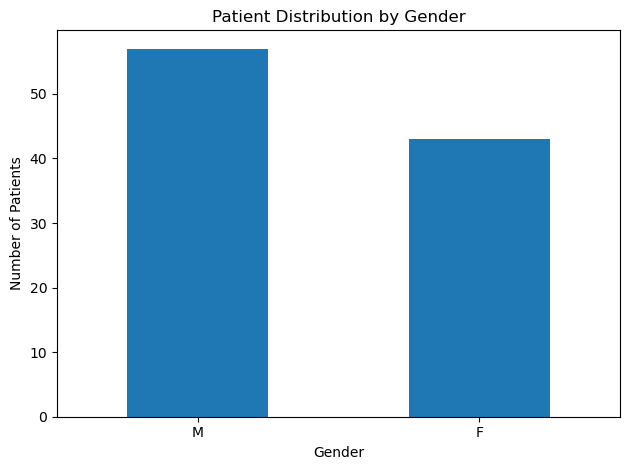

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

gender_distribution.plot(
    x="Gender",
    y="Patients",
    kind="bar",
    legend=False
)

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

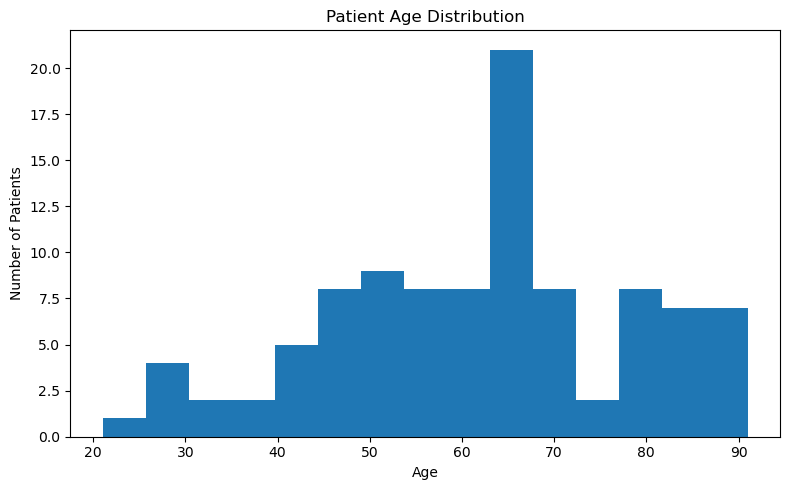

In [99]:
plt.figure(figsize=(8, 5))

plt.hist(
    patients_clean["anchor_age"].dropna(),
    bins=15
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [100]:
patients_clean["anchor_age"].describe()

count    100.00000
mean      61.75000
std       16.16979
min       21.00000
25%       51.75000
50%       63.00000
75%       72.00000
max       91.00000
Name: anchor_age, dtype: float64

In [101]:
admission_distribution = (
    admissions_clean["admission_type_group"]
    .value_counts()
    .reset_index()
)

admission_distribution.columns = [
    "Admission Type",
    "Admissions"
]

admission_distribution

,Admission Type,Admissions
0,Other,224
1,Urgent,38
2,Elective,13


<Figure size 800x500 with 0 Axes>

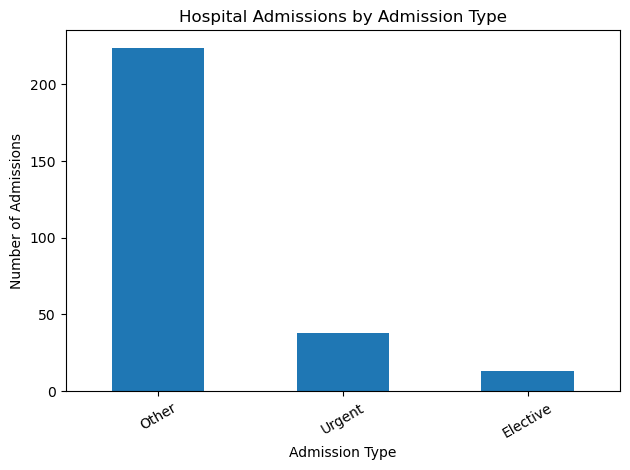

In [102]:
plt.figure(figsize=(8, 5))

admission_distribution.plot(
    x="Admission Type",
    y="Admissions",
    kind="bar",
    legend=False
)

plt.title("Hospital Admissions by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

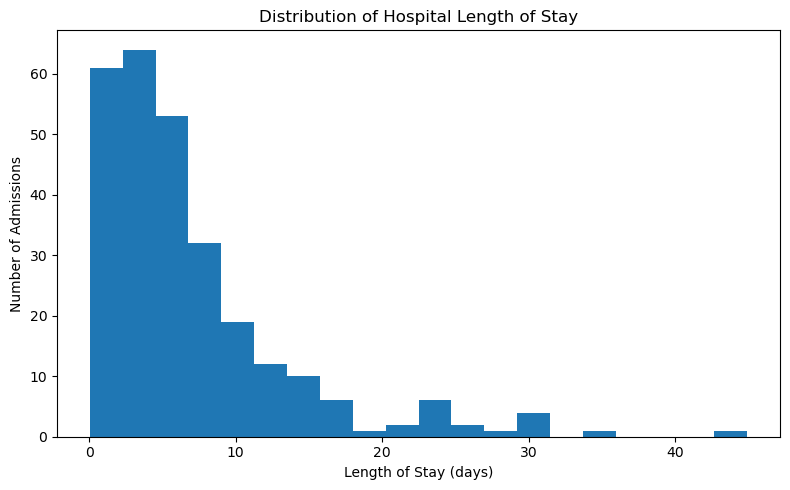

In [103]:
plt.figure(figsize=(8, 5))

plt.hist(
    admissions_clean["length_of_stay_days"].dropna(),
    bins=20
)

plt.title("Distribution of Hospital Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

In [104]:
admissions_clean[
    "length_of_stay_days"
].describe()

count    275.000000
mean       6.875530
std        6.733832
min        0.046528
25%        2.692014
50%        4.852778
75%        8.768403
max       44.927778
Name: length_of_stay_days, dtype: float64

In [105]:
los_distribution = (
    admissions_clean["los_category"]
    .value_counts(sort=False)
)

los_distribution

los_category
≤1 day       30
2-3 days     57
4-7 days     97
8-14 days    60
>14 days     31
Name: count, dtype: int64

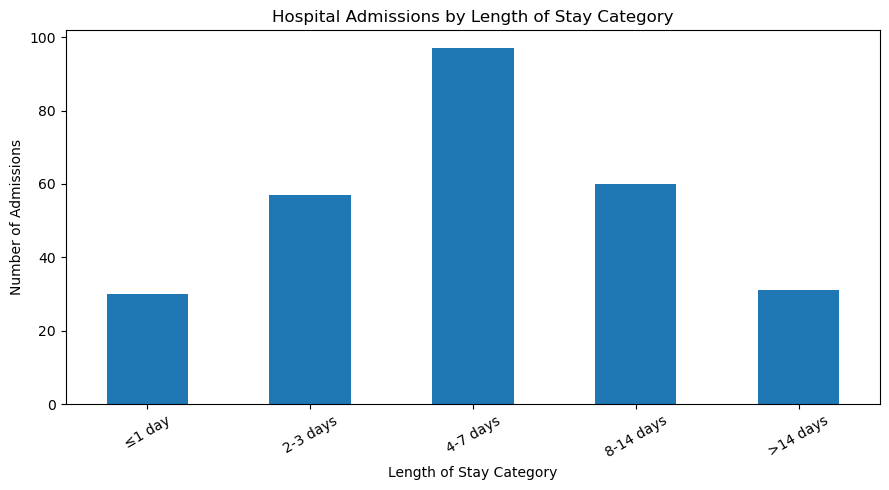

In [106]:
plt.figure(figsize=(9, 5))

los_distribution.plot(
    kind="bar"
)

plt.title("Hospital Admissions by Length of Stay Category")
plt.xlabel("Length of Stay Category")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [107]:
los_by_admission_type = (
    admissions_clean
    .groupby("admission_type_group")[
        "length_of_stay_days"
    ]
    .agg(
        ["count", "mean", "median"]
    )
    .reset_index()
)

los_by_admission_type

,admission_type_group,count,mean,median
0,Elective,13,8.190759,6.188194
1,Other,224,6.294460,4.526389
2,Urgent,38,9.850841,7.855556


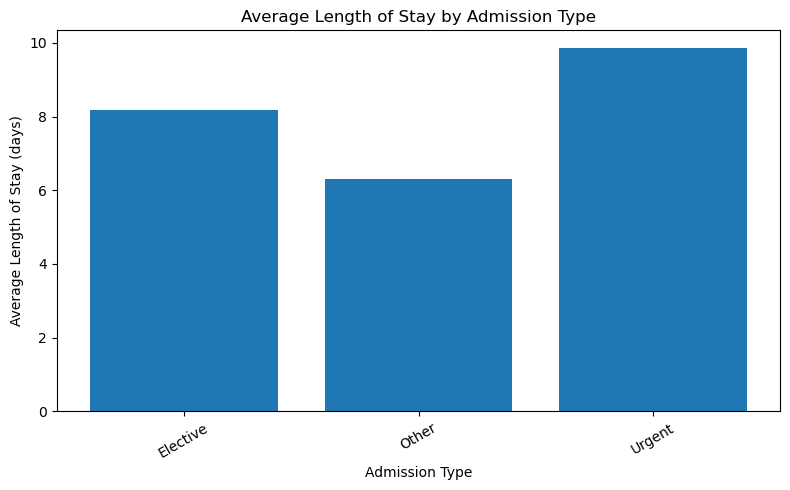

In [108]:
plt.figure(figsize=(8, 5))

plt.bar(
    los_by_admission_type["admission_type_group"],
    los_by_admission_type["mean"]
)

plt.title("Average Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Length of Stay (days)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [109]:
mortality_distribution = (
    admissions_clean["in_hospital_death"]
    .value_counts()
    .sort_index()
)

mortality_distribution

in_hospital_death
0    260
1     15
Name: count, dtype: int64

In [110]:
mortality_labels = (
    admissions_clean["in_hospital_death"]
    .map({
        0: "Survived",
        1: "Died"
    })
    .value_counts()
)

mortality_labels

in_hospital_death
Survived    260
Died         15
Name: count, dtype: int64

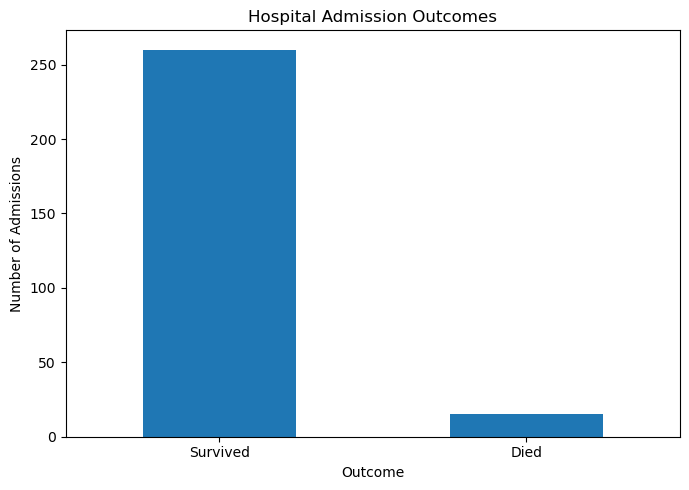

In [111]:
plt.figure(figsize=(7, 5))

mortality_labels.plot(
    kind="bar"
)

plt.title("Hospital Admission Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [112]:
mortality_by_admission = (
    admissions_clean
    .groupby("admission_type_group")
    .agg(
        Admissions=("hadm_id", "count"),
        Deaths=("in_hospital_death", "sum")
    )
    .reset_index()
)

In [113]:
mortality_by_admission["Mortality Rate (%)"] = (
    mortality_by_admission["Deaths"]
    / mortality_by_admission["Admissions"]
    * 100
)

mortality_by_admission

,admission_type_group,Admissions,Deaths,Mortality Rate (%)
0,Elective,13,0,0.000000
1,Other,224,10,4.464286
2,Urgent,38,5,13.157895


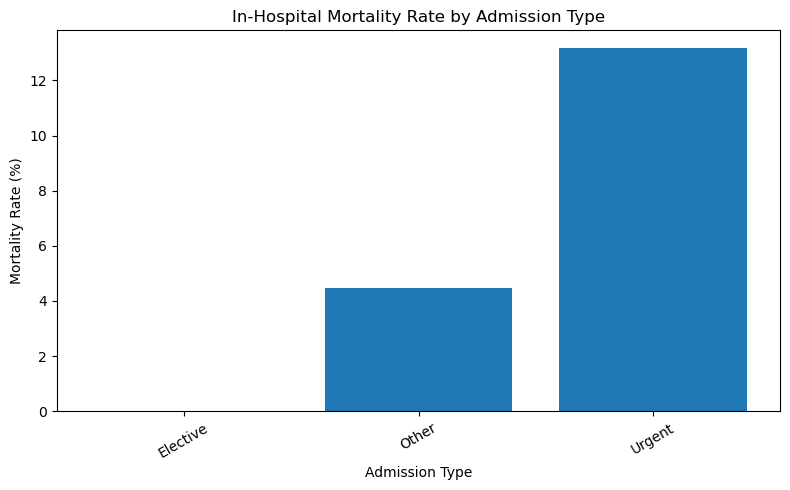

In [114]:
plt.figure(figsize=(8, 5))

plt.bar(
    mortality_by_admission["admission_type_group"],
    mortality_by_admission["Mortality Rate (%)"]
)

plt.title("In-Hospital Mortality Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Mortality Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [115]:
mortality_by_age = (
    hospital_analytics
    .groupby("age_group")
    .agg(
        Admissions=("hadm_id", "count"),
        Deaths=("in_hospital_death", "sum")
    )
    .reset_index()
)

C:\Users\Dr Umar Mht\AppData\Local\Temp\ipykernel_13100\2938284970.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_group")


In [116]:
mortality_by_age["Mortality Rate (%)"] = (
    mortality_by_age["Deaths"]
    / mortality_by_age["Admissions"]
    * 100
)

mortality_by_age

,age_group,Admissions,Deaths,Mortality Rate (%)
0,<18,0,0,NaN
1,18-29,10,0,0.000000
2,30-44,16,0,0.000000
3,45-59,93,2,2.150538
4,60-74,102,9,8.823529
5,75+,54,4,7.407407


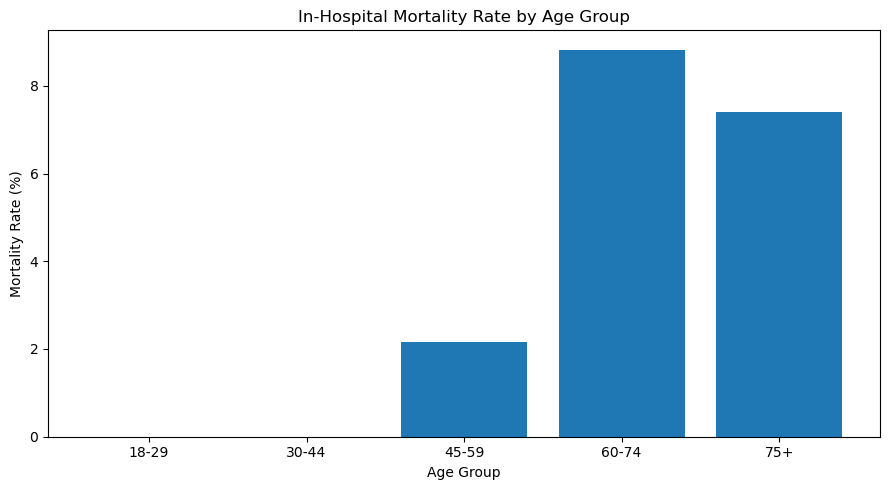

In [117]:
plt.figure(figsize=(9, 5))

plt.bar(
    mortality_by_age["age_group"].astype(str),
    mortality_by_age["Mortality Rate (%)"]
)

plt.title("In-Hospital Mortality Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mortality Rate (%)")

plt.tight_layout()
plt.show()

In [118]:
mortality_by_gender = (
    hospital_analytics
    .groupby("gender")
    .agg(
        Admissions=("hadm_id", "count"),
        Deaths=("in_hospital_death", "sum")
    )
    .reset_index()
)

mortality_by_gender["Mortality Rate (%)"] = (
    mortality_by_gender["Deaths"]
    / mortality_by_gender["Admissions"]
    * 100
)

mortality_by_gender

,gender,Admissions,Deaths,Mortality Rate (%)
0,F,133,3,2.255639
1,M,142,12,8.450704


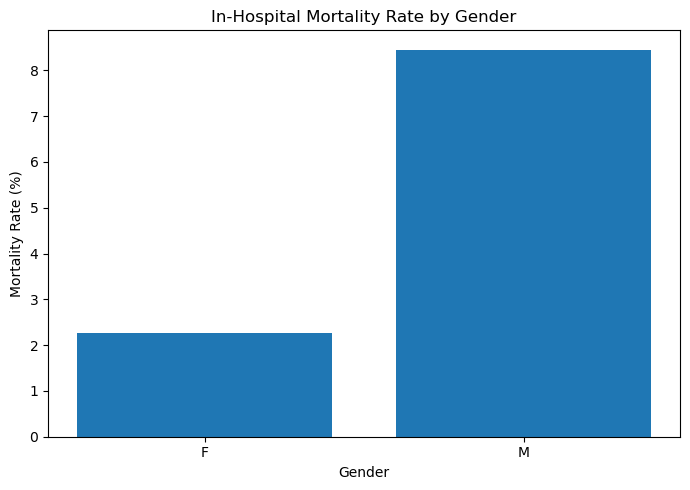

In [119]:
plt.figure(figsize=(7, 5))

plt.bar(
    mortality_by_gender["gender"],
    mortality_by_gender["Mortality Rate (%)"]
)

plt.title("In-Hospital Mortality Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Mortality Rate (%)")

plt.tight_layout()
plt.show()

In [120]:
readmission_distribution = (
    admissions_clean["readmission_30d"]
    .value_counts()
    .sort_index()
)

readmission_distribution

readmission_30d
0    222
1     53
Name: count, dtype: int64

In [121]:
readmission_labels = (
    admissions_clean["readmission_30d"]
    .map({
        0: "No 30-Day Readmission",
        1: "30-Day Readmission"
    })
    .value_counts()
)

readmission_labels

readmission_30d
No 30-Day Readmission    222
30-Day Readmission        53
Name: count, dtype: int64

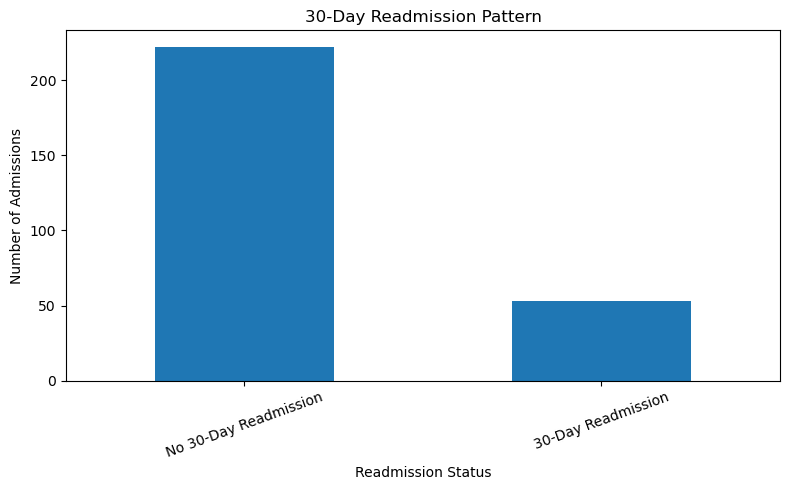

In [122]:
plt.figure(figsize=(8, 5))

readmission_labels.plot(
    kind="bar"
)

plt.title("30-Day Readmission Pattern")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [123]:
transfer_distribution = (
    admissions_clean["transfer_count"]
    .describe()
)

transfer_distribution

count    275.000000
mean       4.130909
std        1.590675
min        2.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       10.000000
Name: transfer_count, dtype: float64

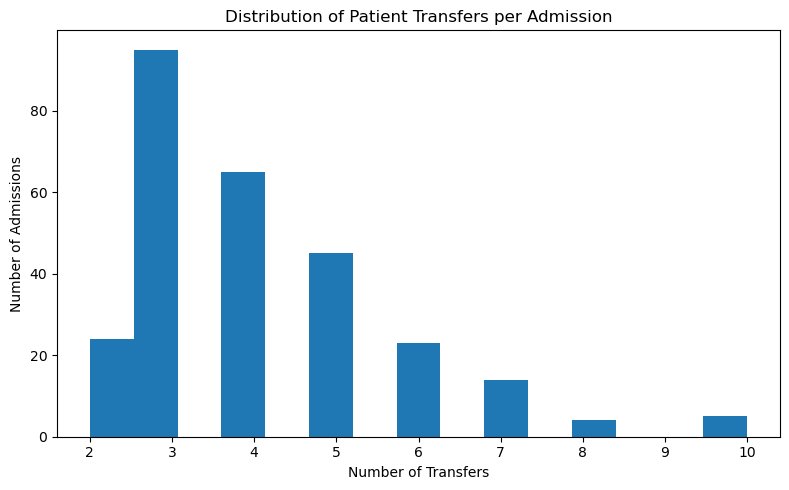

In [124]:
plt.figure(figsize=(8, 5))

plt.hist(
    admissions_clean["transfer_count"],
    bins=15
)

plt.title("Distribution of Patient Transfers per Admission")
plt.xlabel("Number of Transfers")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

In [125]:
transfer_los = (
    admissions_clean[
        ["transfer_count", "length_of_stay_days"]
    ]
    .dropna()
)

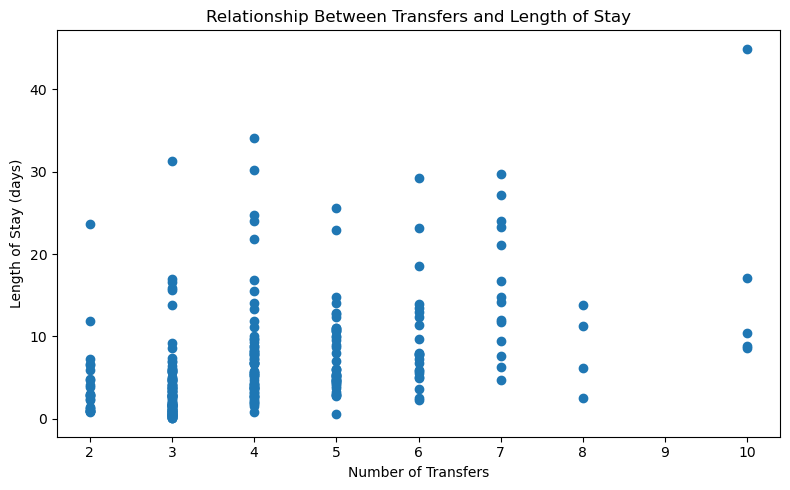

In [126]:
plt.figure(figsize=(8, 5))

plt.scatter(
    transfer_los["transfer_count"],
    transfer_los["length_of_stay_days"]
)

plt.title(
    "Relationship Between Transfers and Length of Stay"
)

plt.xlabel("Number of Transfers")
plt.ylabel("Length of Stay (days)")

plt.tight_layout()
plt.show()

In [127]:
transfer_los.corr()

,transfer_count,length_of_stay_days
transfer_count,1.000000,0.453506
length_of_stay_days,0.453506,1.000000


In [128]:
transfer_los[
    "transfer_count"
].corr(
    transfer_los["length_of_stay_days"]
)

np.float64(0.4535058339879566)

In [129]:
careunit_distribution = (
    transfers_clean["careunit"]
    .value_counts(dropna=False)
    .reset_index()
)

careunit_distribution.columns = [
    "Care Unit",
    "Transfers"
]

careunit_distribution.head(15)

,Care Unit,Transfers
0,NaN,311
1,Emergency Department,236
2,Medicine,76
3,Med/Surg,48
4,Neurology,46
5,Medicine/Cardiology,43
6,Transplant,39
7,Cardiac Surgery,39
8,Medical Intensive Care Unit (MICU),36
9,Surgical Intensive Care Unit (SICU),33


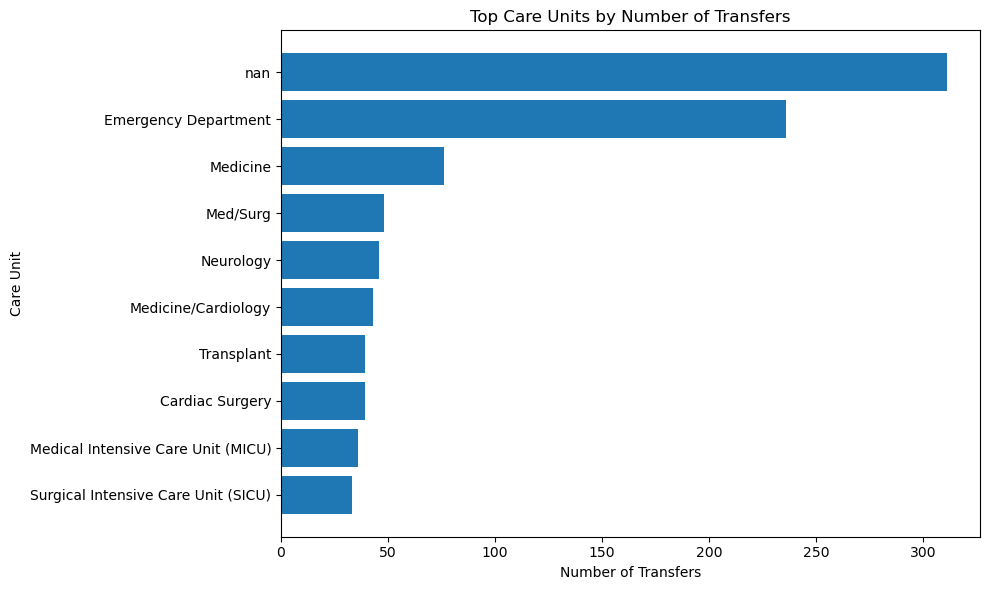

In [130]:
top_careunits = careunit_distribution.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_careunits["Care Unit"].astype(str),
    top_careunits["Transfers"]
)

plt.title("Top Care Units by Number of Transfers")
plt.xlabel("Number of Transfers")
plt.ylabel("Care Unit")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [131]:
performance_by_admission = (
    admissions_clean
    .groupby("admission_type_group")
    .agg(
        Admissions=("hadm_id", "count"),
        Average_LOS=("length_of_stay_days", "mean"),
        Median_LOS=("length_of_stay_days", "median"),
        Deaths=("in_hospital_death", "sum"),
        Readmissions_30d=("readmission_30d", "sum"),
        Average_Transfers=("transfer_count", "mean")
    )
    .reset_index()
)

In [132]:
performance_by_admission["Mortality_Rate_%"] = (
    performance_by_admission["Deaths"]
    / performance_by_admission["Admissions"]
    * 100
)

In [133]:
performance_by_admission["Readmission_Rate_%"] = (
    performance_by_admission["Readmissions_30d"]
    / performance_by_admission["Admissions"]
    * 100
)

In [134]:
numeric_variables = hospital_analytics[
    [
        "anchor_age",
        "length_of_stay_days",
        "transfer_count",
        "in_hospital_death",
        "readmission_30d"
    ]
]

In [135]:
correlation_matrix = numeric_variables.corr()

correlation_matrix

,anchor_age,length_of_stay_days,transfer_count,in_hospital_death,readmission_30d
anchor_age,1.000000,-0.027647,-0.009306,0.124804,-0.092299
length_of_stay_days,-0.027647,1.000000,0.453506,0.144360,0.069185
transfer_count,-0.009306,0.453506,1.000000,0.081047,0.017778
in_hospital_death,0.124804,0.144360,0.081047,1.000000,-0.076764
readmission_30d,-0.092299,0.069185,0.017778,-0.076764,1.000000


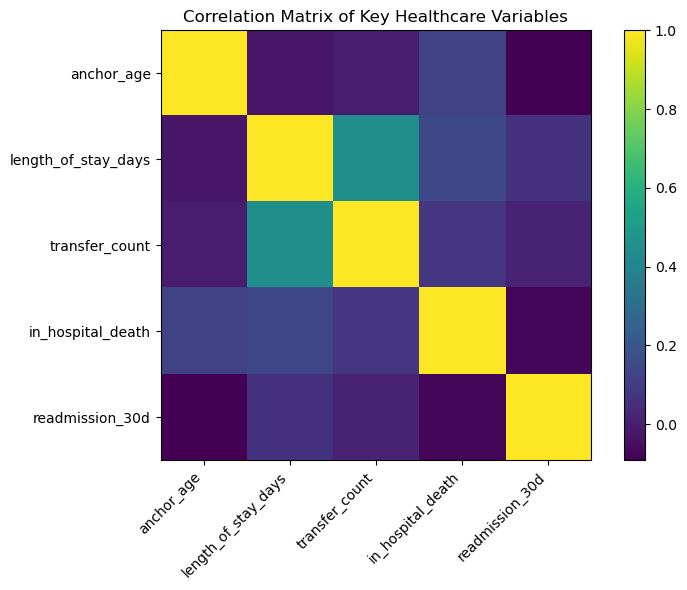

In [136]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Key Healthcare Variables")

plt.tight_layout()
plt.show()

In [137]:
### Key Analytical Questions

The exploratory analysis is designed to answer several healthcare management questions:

1. What are the demographic characteristics of the patient population?

2. Which admission types account for the largest proportion of hospital admissions?

3. What is the distribution of hospital length of stay?

4. Which admission types are associated with longer hospital stays?

5. What is the overall in-hospital mortality rate?

6. Does mortality vary across age groups and admission types?

7. How common are 30-day readmissions?

8. Are certain patient groups associated with higher readmission rates?

9. How frequently are patients transferred between hospital care units?

10. Is higher transfer activity associated with longer hospital stays?

11. Which care units account for the largest number of recorded transfers?

These questions will guide the development of the final healthcare performance dashboard.

SyntaxError: invalid syntax (473212694.py, line 3)

In [ ]:
### Exploratory Data Analysis Summary

The exploratory analysis examined patient demographics, hospital utilization, length of stay, mortality, readmissions, and patient transfers.

The analysis provides a detailed understanding of:

- Patient demographic distribution
- Hospital admission patterns
- Length-of-stay distribution
- Mortality patterns
- 30-day readmission patterns
- Transfer activity
- Care-unit utilization
- Relationships between hospital utilization and patient outcomes

The findings from EDA will be used to identify the most relevant indicators and visualizations for the Power BI dashboard.

Importantly, observed associations will be interpreted cautiously and will not be considered evidence of causality.

In [ ]:
# 8. Final Data Preparation & Export

This section prepares the final analytical datasets for Power BI.

The processed datasets contain cleaned variables, engineered healthcare indicators, and patient-level information required for hospital performance analysis.

The main analytical dataset exported for Power BI is:

`hospital_analytics.csv`

In [138]:
hospital_analytics.columns.tolist()

['subject_id',
 'hadm_id',
 'admittime',
 'dischtime',
 'deathtime',
 'admission_type',
 'admission_location',
 'discharge_location',
 'insurance',
 'language',
 'marital_status',
 'ethnicity',
 'edregtime',
 'edouttime',
 'hospital_expire_flag',
 'length_of_stay_days',
 'in_hospital_death',
 'los_category',
 'long_stay',
 'admission_type_group',
 'transfer_count',
 'high_transfer',
 'previous_discharge',
 'days_since_previous_discharge',
 'readmission_30d',
 'readmission_eligible',
 'gender',
 'anchor_age',
 'age_group',
 'admission_count',
 'multiple_admissions']

In [139]:
hospital_analytics_final = hospital_analytics.copy()

In [140]:
final_columns = [
    "subject_id",
    "hadm_id",
    "gender",
    "anchor_age",
    "age_group",
    "admittime",
    "dischtime",
    "deathtime",
    "admission_type",
    "admission_type_group",
    "admission_location",
    "discharge_location",
    "insurance",
    "marital_status",
    "race",
    "length_of_stay_days",
    "los_category",
    "long_stay",
    "in_hospital_death",
    "transfer_count",
    "high_transfer",
    "previous_discharge",
    "days_since_previous_discharge",
    "readmission_eligible",
    "readmission_30d",
    "admission_count",
    "multiple_admissions"
]

In [142]:
print("Rows:", hospital_analytics_final.shape[0])
print("Columns:", hospital_analytics_final.shape[1])

Rows: 275
Columns: 31


In [143]:
hospital_analytics_final.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,ethnicity,edregtime,edouttime,hospital_expire_flag,length_of_stay_days,in_hospital_death,los_category,long_stay,admission_type_group,transfer_count,high_transfer,previous_discharge,days_since_previous_discharge,readmission_30d,readmission_eligible,gender,anchor_age,age_group,admission_count,multiple_admissions
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,0.786111,0,≤1 day,0,Urgent,3,0,NaT,NaN,0,0,F,52,45-59,4,1
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,1.015278,0,2-3 days,0,Other,3,0,2180-05-07 17:15:00,50.050000,0,1,F,52,45-59,4,1
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,2.222222,0,2-3 days,0,Other,6,1,2180-06-27 18:49:00,25.740278,1,1,F,52,45-59,4,1
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,1.754167,0,2-3 days,0,Other,3,0,2180-07-25 17:55:00,11.242361,1,1,F,52,45-59,4,1
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,?,MARRIED,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,6.794444,0,4-7 days,0,Other,6,1,NaT,NaN,0,0,F,55,45-59,2,1


In [144]:
hospital_analytics_final.isnull().sum()

subject_id                         0
hadm_id                            0
admittime                          0
dischtime                          0
deathtime                        260
admission_type                     0
admission_location                 0
discharge_location                42
insurance                          0
language                           0
marital_status                    12
ethnicity                          0
edregtime                         94
edouttime                         94
hospital_expire_flag               0
length_of_stay_days                0
in_hospital_death                  0
los_category                       0
long_stay                          0
admission_type_group               0
transfer_count                     0
high_transfer                      0
previous_discharge               100
days_since_previous_discharge    100
readmission_30d                    0
readmission_eligible               0
gender                             0
a

In [146]:
from pathlib import Path

processed_path = Path("C:/data/processed")

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed folder:")
print(processed_path.resolve())

Processed folder:
C:\data\processed


In [147]:
hospital_analytics.to_csv(
    processed_path / "hospital_analytics.csv",
    index=False
)

print("hospital_analytics.csv exported successfully.")

hospital_analytics.csv exported successfully.


In [148]:
output_file = processed_path / "hospital_analytics.csv"

print("File exists:", output_file.exists())
print("File location:", output_file)

File exists: True
File location: C:\data\processed\hospital_analytics.csv
